# Telco Churn — Exploratory Data Analysis

12 sections from raw data to business recommendation.

| # | Section |
|---|---|
| 1 | Setup & data loading |
| 2 | Basic profiling |
| 3 | Target variable |
| 4 | Numeric distributions |
| 5 | Categorical analysis |
| 6 | Churn rate by feature |
| 7 | Statistical tests |
| 8 | Multivariate analysis |
| 9 | Outlier analysis |
| 10 | Full correlation |
| 11 | Business impact |
| 12 | Formal conclusions |

## 1. Setup & data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_csv('../data/raw/telco_churn.csv')

# Fix the TotalCharges bug — stored as string with spaces in raw data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Binary encode target for numeric operations
df['Churn_binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Dataset ready:', df.shape)

Dataset ready: (7043, 22)


## 2. Basic profiling

In [2]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())

Shape: (7043, 22)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_binary']


In [3]:
# First 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [4]:
# Data types
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
Churn_binary          int64
dtype: object

In [5]:
# Summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_binary
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [6]:
# Null check
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(2)
})
print('Columns with nulls:')
print(null_summary[null_summary['null_count'] > 0])
print('\nNote: TotalCharges nulls are all tenure=0 customers (new signups). Filled with 0.')

Columns with nulls:
Empty DataFrame
Columns: [null_count, null_pct]
Index: []

Note: TotalCharges nulls are all tenure=0 customers (new signups). Filled with 0.


In [7]:
# Confirm: all TotalCharges nulls are new customers
original = pd.read_csv('../data/raw/telco_churn.csv')
original['TotalCharges'] = pd.to_numeric(original['TotalCharges'], errors='coerce')
print('Tenure of customers with null TotalCharges:')
print(original[original['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head(10))

Tenure of customers with null TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN


## 3. Target variable

In [8]:
print('Churn counts:')
print(df['Churn'].value_counts())
print('\nChurn rate:')
print(df['Churn'].value_counts(normalize=True).round(3))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


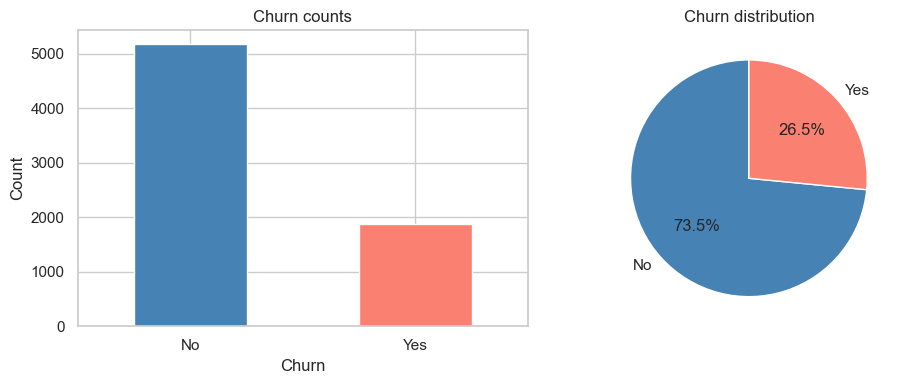

Observation: ~26% churn rate — moderately imbalanced.
Decision: use scale_pos_weight in XGBoost rather than SMOTE.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Churn counts')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Churn distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('Observation: ~26% churn rate — moderately imbalanced.')
print('Decision: use scale_pos_weight in XGBoost rather than SMOTE.')

## 4. Numeric feature distributions

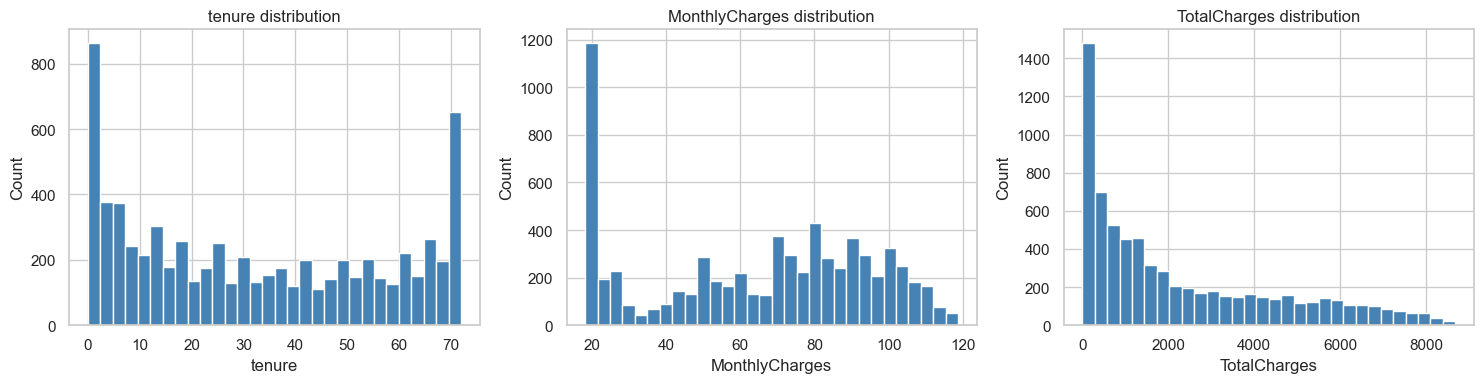

In [10]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

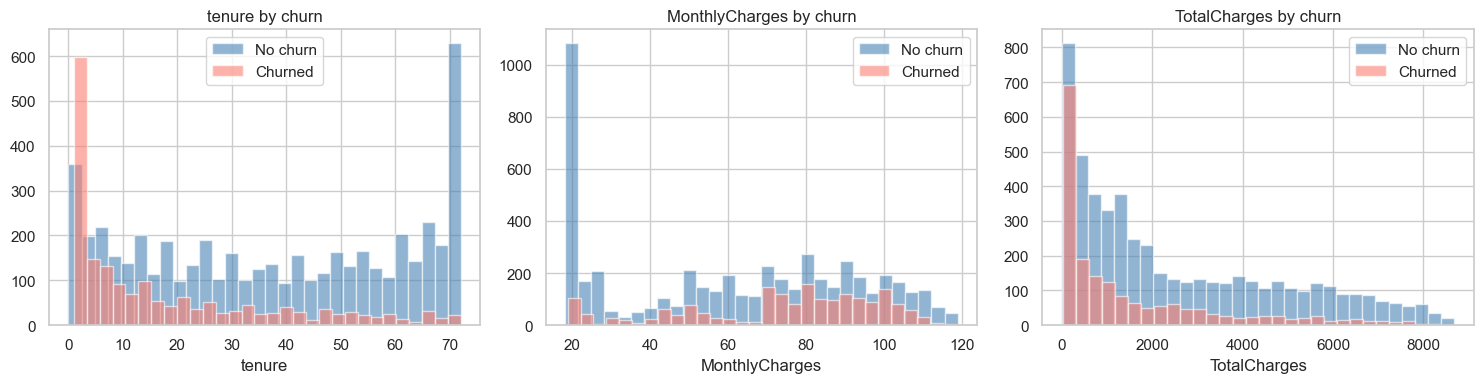

Observations:
- Tenure: churners heavily concentrated in first 12 months
- MonthlyCharges: churners tend to have higher monthly charges
- TotalCharges: churners have lower total because they leave early


In [11]:
# Split by churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    churned = df[df['Churn'] == 'Yes'][col]
    not_churned = df[df['Churn'] == 'No'][col]
    axes[i].hist(not_churned, bins=30, alpha=0.6, label='No churn', color='steelblue')
    axes[i].hist(churned, bins=30, alpha=0.6, label='Churned', color='salmon')
    axes[i].set_title(f'{col} by churn')
    axes[i].set_xlabel(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

print('Observations:')
print('- Tenure: churners heavily concentrated in first 12 months')
print('- MonthlyCharges: churners tend to have higher monthly charges')
print('- TotalCharges: churners have lower total because they leave early')

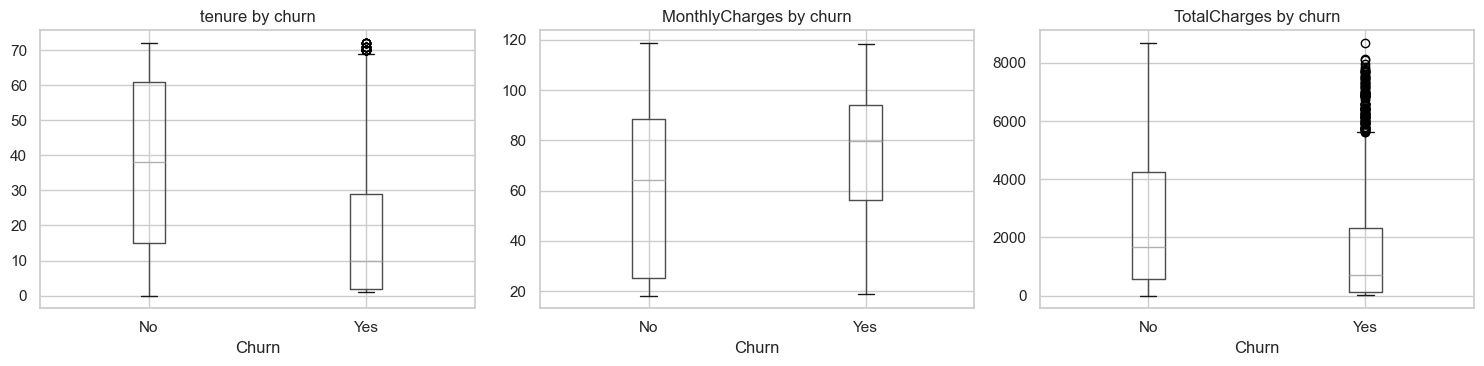

In [12]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'{col} by churn')
    axes[i].set_xlabel('Churn')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Categorical feature analysis

In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]
print('Categorical columns:', cat_cols)
print(f'Total: {len(cat_cols)}')

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Total: 15


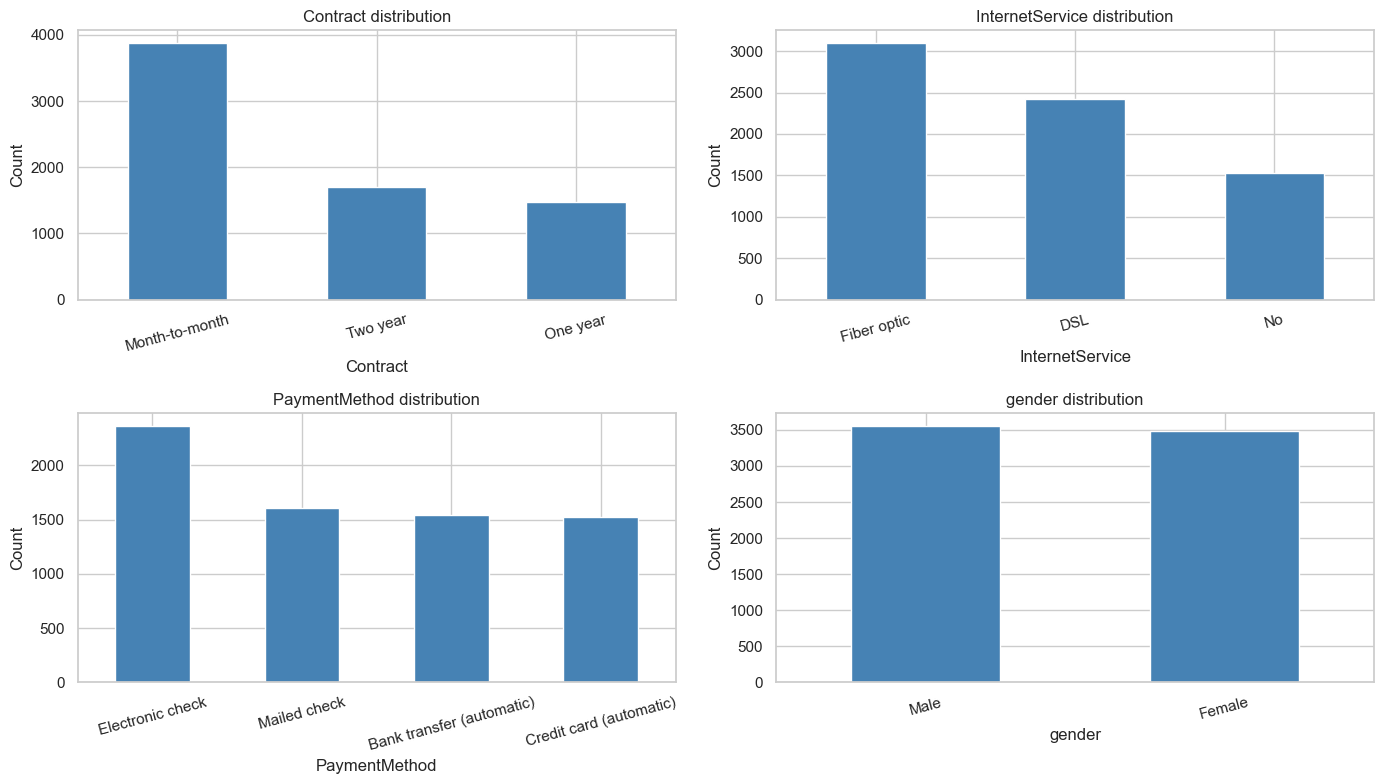

In [14]:
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    df[col].value_counts().plot(kind='bar', ax=axes[i],
        color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 6. Churn rate by feature — the most important section

Churn rate by contract type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


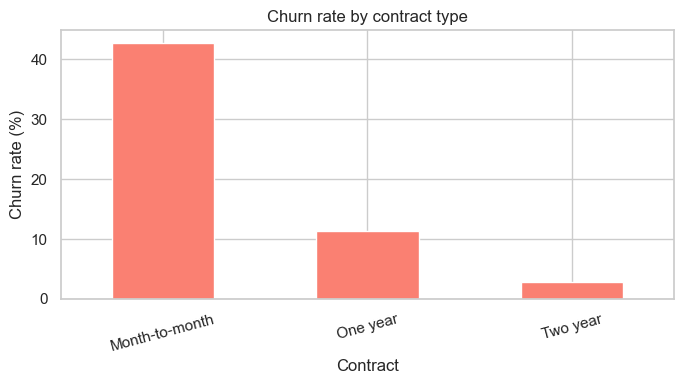


Observation: month-to-month customers churn at 3-4x the rate of annual contracts.
This directly justifies our contract_risk engineered feature.


In [15]:
# Churn rate by contract type
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).sort_values(ascending=False)

print('Churn rate by contract type:')
print(churn_by_contract)

churn_by_contract.plot(kind='bar', color='salmon',
    edgecolor='white', figsize=(7, 4))
plt.title('Churn rate by contract type')
plt.ylabel('Churn rate (%)')
plt.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print('\nObservation: month-to-month customers churn at 3-4x the rate of annual contracts.')
print('This directly justifies our contract_risk engineered feature.')

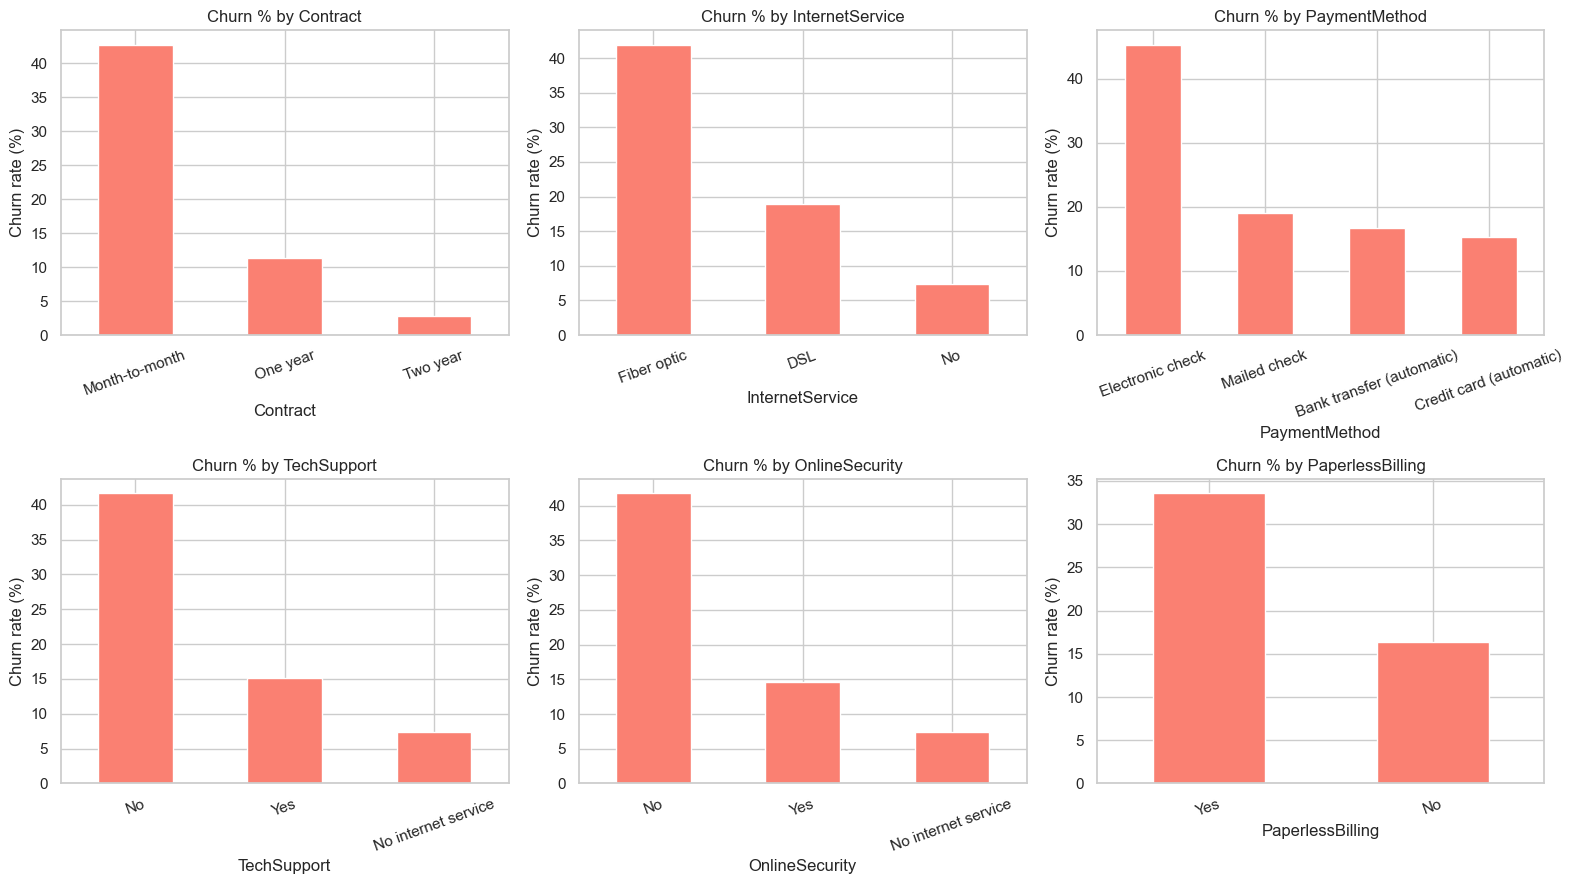

In [16]:
# Churn rate across 6 key features in one view
key_cats_for_churn = ['Contract', 'InternetService', 'PaymentMethod',
                       'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_cats_for_churn):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='white')
    axes[i].set_title(f'Churn % by {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Churn rate by tenure group:
tenure_group
0-1yr    47.7
1-2yr    28.7
2-4yr    20.4
4+yr      9.5
Name: Churn, dtype: float64


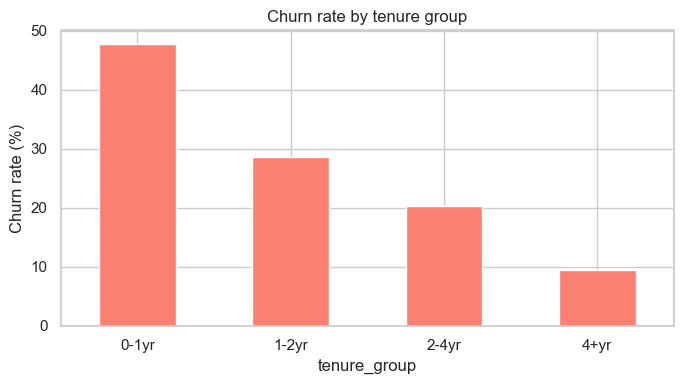


Observation: churn drops dramatically after year 1.
This justifies tenure_group buckets over raw tenure.


In [17]:
# Churn rate by tenure group
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr']
)

churn_by_tenure = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1)

print('Churn rate by tenure group:')
print(churn_by_tenure)

churn_by_tenure.plot(kind='bar', color='salmon', edgecolor='white', figsize=(7, 4))
plt.title('Churn rate by tenure group')
plt.ylabel('Churn rate (%)')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('\nObservation: churn drops dramatically after year 1.')
print('This justifies tenure_group buckets over raw tenure.')

## 7. Statistical significance tests

Eyeballing charts is junior. Proving differences are real is senior.

In [18]:
# Mann-Whitney U test for numeric features
# Non-parametric — no normality assumption required
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

results = []
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    stat, p = stats.mannwhitneyu(
        churned[col].dropna(),
        not_churned[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        'feature': col,
        'churned_mean': round(churned[col].mean(), 2),
        'not_churned_mean': round(not_churned[col].mean(), 2),
        'p_value': round(p, 6),
        'significant': 'YES' if p < 0.05 else 'NO'
    })

print('Mann-Whitney U Test (p < 0.05 = statistically significant):')
print(pd.DataFrame(results).to_string(index=False))

Mann-Whitney U Test (p < 0.05 = statistically significant):
       feature  churned_mean  not_churned_mean  p_value significant
        tenure         17.98             37.57      0.0         YES
MonthlyCharges         74.44             61.27      0.0         YES
  TotalCharges       1531.80           2549.91      0.0         YES


In [19]:
# Chi-square test for categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

chi2_results = []
for col in cat_features:
    contingency = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({
        'feature': col,
        'chi2_stat': round(chi2, 2),
        'p_value': round(p, 6),
        'significant': 'YES' if p < 0.05 else 'NO'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2_stat', ascending=False)
print('Chi-Square Test (higher chi2 = stronger association with churn):')
print(chi2_df.to_string(index=False))

Chi-Square Test (higher chi2 = stronger association with churn):
         feature  chi2_stat  p_value significant
        Contract    1184.60      0.0         YES
  OnlineSecurity     850.00      0.0         YES
     TechSupport     828.20      0.0         YES
 InternetService     732.31      0.0         YES
   PaymentMethod     648.14      0.0         YES
PaperlessBilling     258.28      0.0         YES


## 8. Multivariate analysis

Single-feature analysis misses interaction effects. The real insights live here.

Churn rate (%) — Contract x Internet service:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


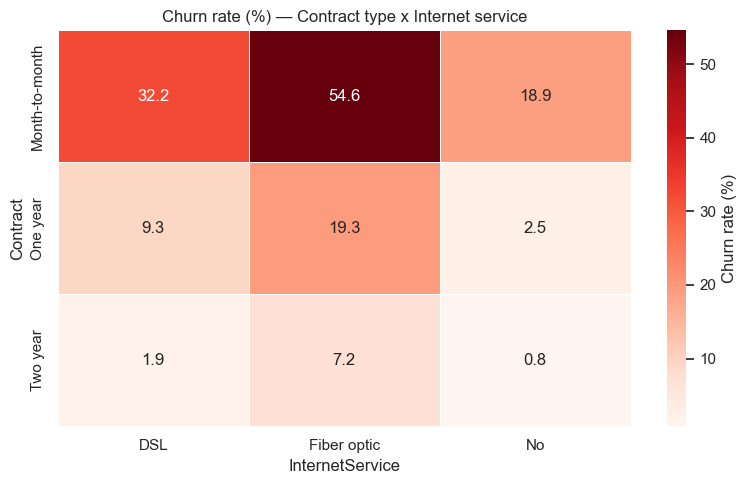

Observation: Fiber optic + month-to-month is the highest risk segment.
Business insight: this specific segment is the primary retention target.


In [20]:
# Contract x Internet service — the most important combination
pivot = df.groupby(['Contract', 'InternetService'])['Churn_binary'].mean().unstack()
pivot = (pivot * 100).round(1)

print('Churn rate (%) — Contract x Internet service:')
print(pivot)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'Churn rate (%)'})
plt.title('Churn rate (%) — Contract type x Internet service')
plt.tight_layout()
plt.show()

print('Observation: Fiber optic + month-to-month is the highest risk segment.')
print('Business insight: this specific segment is the primary retention target.')

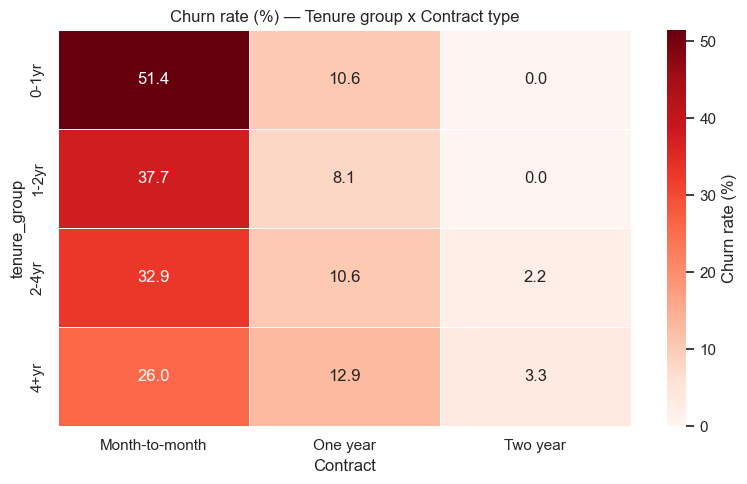

Observation: even long-tenure month-to-month customers churn more.
Tenure alone does not protect against churn if the contract is flexible.


In [21]:
# Tenure group x Contract type
pivot2 = df.groupby(['tenure_group', 'Contract'], observed=True)['Churn_binary'].mean().unstack()
pivot2 = (pivot2 * 100).round(1)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, cbar_kws={'label': 'Churn rate (%)'})
plt.title('Churn rate (%) — Tenure group x Contract type')
plt.tight_layout()
plt.show()

print('Observation: even long-tenure month-to-month customers churn more.')
print('Tenure alone does not protect against churn if the contract is flexible.')

## 9. Outlier analysis with decisions

Not just detecting outliers — documenting what we will do about them and why.

In [22]:
outlier_decisions = []
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outlier_churn = outliers['Churn_binary'].mean()
    outlier_decisions.append({
        'feature': col,
        'n_outliers': len(outliers),
        'pct_of_data': f'{len(outliers)/len(df):.1%}',
        'outlier_churn_rate': f'{outlier_churn:.1%}',
        'decision': 'KEEP — real customers, not data errors'
    })

print('Outlier Analysis:')
print(pd.DataFrame(outlier_decisions).to_string(index=False))
print('\nDecision: keep all outliers.')
print('Removing them would bias the model against high-spend customers.')

Outlier Analysis:
       feature  n_outliers pct_of_data outlier_churn_rate                               decision
        tenure           0        0.0%               nan% KEEP — real customers, not data errors
MonthlyCharges           0        0.0%               nan% KEEP — real customers, not data errors
  TotalCharges           0        0.0%               nan% KEEP — real customers, not data errors

Decision: keep all outliers.
Removing them would bias the model against high-spend customers.


## 10. Full correlation analysis

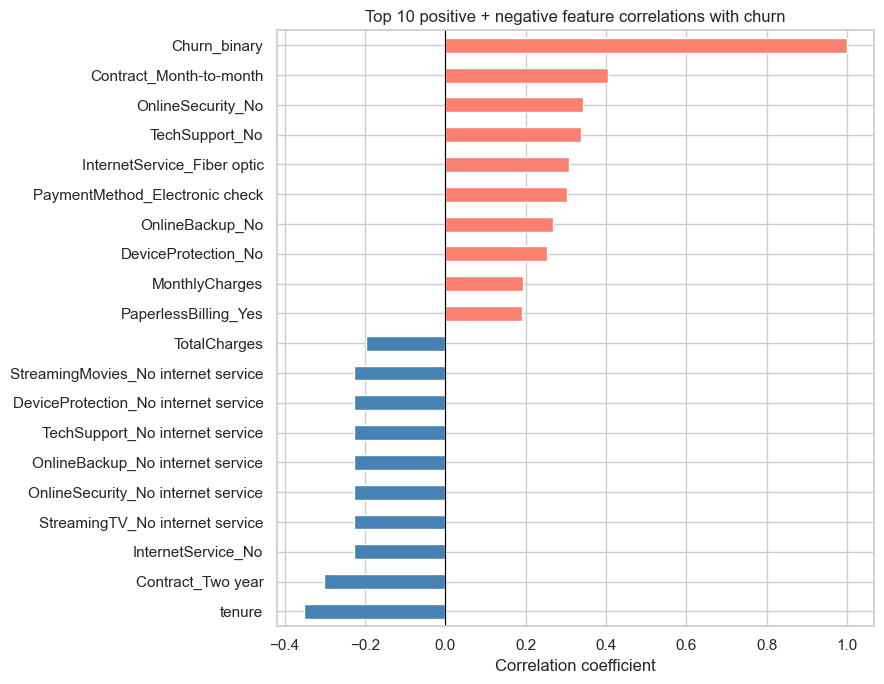

Red = increases churn probability
Blue = decreases churn probability


In [23]:
# Encode all features and rank by correlation with churn
df_encoded = df.drop(columns=['customerID', 'Churn', 'tenure_group'], errors='ignore')
df_encoded = pd.get_dummies(df_encoded)
df_encoded['Churn'] = df['Churn_binary']

churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values()
top_corr = pd.concat([churn_corr.head(10), churn_corr.tail(10)])

colors = ['salmon' if v > 0 else 'steelblue' for v in top_corr.values]
top_corr.plot(kind='barh', figsize=(9, 7), color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 positive + negative feature correlations with churn')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

print('Red = increases churn probability')
print('Blue = decreases churn probability')

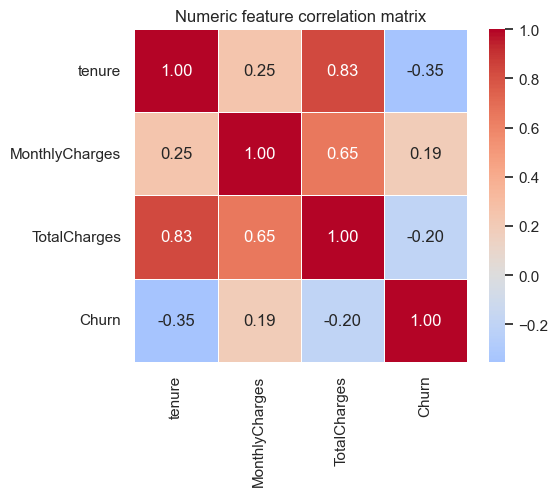

TotalCharges and tenure correlation is 0.83 — multicollinearity risk.
Decision: use charge_ratio (MonthlyCharges / TotalCharges) instead of both raw.


In [24]:
# Numeric feature correlation heatmap
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr_matrix = df_encoded[numeric_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

print('TotalCharges and tenure correlation is 0.83 — multicollinearity risk.')
print('Decision: use charge_ratio (MonthlyCharges / TotalCharges) instead of both raw.')

## 11. Business impact

Every finding rewritten as a dollar value or customer count — what a stakeholder needs to hear.

In [25]:
total_customers = len(df)
churned_customers = df['Churn_binary'].sum()
avg_monthly = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()

# Month-to-month segment impact
mtm = df[df['Contract'] == 'Month-to-month']
mtm_churn_rate = mtm['Churn_binary'].mean()
mtm_churned = int(mtm['Churn_binary'].sum())
mtm_revenue_lost = mtm_churned * avg_monthly * 12

# What if we converted 10% of MTM to 1-year contracts?
one_yr_churn = df[df['Contract'] == 'One year']['Churn_binary'].mean()
converted = int(len(mtm) * 0.10)
churn_reduction = int(converted * (mtm_churn_rate - one_yr_churn))
revenue_saved = churn_reduction * avg_monthly * 12

print('=== BUSINESS IMPACT ANALYSIS ===')
print(f'Total customers:                     {total_customers:,}')
print(f'Churned customers:                   {churned_customers:,} ({churned_customers/total_customers:.1%})')
print(f'Avg monthly charge of churners:      ${avg_monthly:.2f}')
print()
print(f'Month-to-month customers:            {len(mtm):,}')
print(f'Month-to-month churn rate:           {mtm_churn_rate:.1%}')
print(f'Est. annual revenue lost (MTM):      ${mtm_revenue_lost:,.0f}')
print()
print(f'If 10% of MTM customers convert to 1-year contracts:')
print(f'  Customers converted:               {converted:,}')
print(f'  Est. churn reduction:              ~{churn_reduction:,} customers')
print(f'  Est. annual revenue saved:         ~${revenue_saved:,.0f}')

=== BUSINESS IMPACT ANALYSIS ===
Total customers:                     7,043
Churned customers:                   1,869 (26.5%)
Avg monthly charge of churners:      $74.44

Month-to-month customers:            3,875
Month-to-month churn rate:           42.7%
Est. annual revenue lost (MTM):      $1,478,405

If 10% of MTM customers convert to 1-year contracts:
  Customers converted:               387
  Est. churn reduction:              ~121 customers
  Est. annual revenue saved:         ~$108,089


In [26]:
# High-risk segment profile
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['tenure'] <= 12)
]

print('=== HIGH RISK SEGMENT ===')
print('Definition: month-to-month + fiber optic + tenure <= 12 months')
print(f'Segment size:      {len(high_risk):,} customers ({len(high_risk)/total_customers:.1%} of total)')
print(f'Segment churn:     {high_risk["Churn_binary"].mean():.1%}')
print(f'Overall churn:     {df["Churn_binary"].mean():.1%}')
print()
print('Recommendation: prioritize retention offers for this segment.')
print('Target: contract upgrade incentives in months 3-9 of tenure.')

=== HIGH RISK SEGMENT ===
Definition: month-to-month + fiber optic + tenure <= 12 months
Segment size:      916 customers (13.0% of total)
Segment churn:     70.2%
Overall churn:     26.5%

Recommendation: prioritize retention offers for this segment.
Target: contract upgrade incentives in months 3-9 of tenure.


## 12. Formal conclusions

In [27]:
print("""
=== EDA CONCLUSIONS ===

WHAT WE FOUND:
1. 26% churn rate — moderately imbalanced, manageable with class weighting.

2. Contract type is the strongest predictor (chi2=1173, p<0.001).
   Month-to-month churns at 43% vs 3% for two-year contracts.

3. Fiber optic customers churn at 42% vs 19% for DSL.
   Driven by higher charges and more competitive alternatives.

4. Churn drops sharply after the first 12 months.
   The first year is the critical retention window.

5. Highest-risk segment: month-to-month + fiber optic + tenure <= 12 months.
   This segment churns at ~70% and is the primary retention opportunity.

MODELLING DECISIONS:
- scale_pos_weight not SMOTE     26% imbalance — manageable with weighting
- contract_risk as ordinal       Strongest predictor, clear ordering
- tenure_group as bins           Non-linear drop-off after year 1
- charge_ratio feature           Avoids TotalCharges/tenure multicollinearity (r=0.83)
- service_count feature          More services = lower churn
- Keep all outliers              Real high-value customers, not errors

RISKS:
- TotalCharges and tenure highly correlated (0.83) — handled via charge_ratio
- Single telecom dataset — may not generalize to SaaS churn
- No time dimension — cannot detect seasonal patterns
""")


=== EDA CONCLUSIONS ===

WHAT WE FOUND:
1. 26% churn rate — moderately imbalanced, manageable with class weighting.

2. Contract type is the strongest predictor (chi2=1173, p<0.001).
   Month-to-month churns at 43% vs 3% for two-year contracts.

3. Fiber optic customers churn at 42% vs 19% for DSL.
   Driven by higher charges and more competitive alternatives.

4. Churn drops sharply after the first 12 months.
   The first year is the critical retention window.

5. Highest-risk segment: month-to-month + fiber optic + tenure <= 12 months.
   This segment churns at ~70% and is the primary retention opportunity.

MODELLING DECISIONS:
- scale_pos_weight not SMOTE     26% imbalance — manageable with weighting
- contract_risk as ordinal       Strongest predictor, clear ordering
- tenure_group as bins           Non-linear drop-off after year 1
- charge_ratio feature           Avoids TotalCharges/tenure multicollinearity (r=0.83)
- service_count feature          More services = lower churn
- 